In [1]:
import os

In [ ]:
import os 
import warnings
warnings.filterwarnings("ignore")

**Dataset Link**
https://www.kaggle.com/datasets/gregorut/videogamesales

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Load the dataset
df = pd.read_csv("/kaggle/input/videogamesales/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
for col in df.columns:
    print(df[col].unique())

[    1     2     3 ... 16598 16599 16600]
['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ... 'Plushees'
 'Woody Woodpecker in Crazy Castle 5' 'Know How 2']
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2003. 1986. 2000.   nan 1995. 2016. 1991. 1981. 1987.
 1980. 1983. 2020. 2017.]
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
['Nintendo' 'Microsoft Game Studios' 'Take-Two Interactive'
 'Sony Computer Entertainment' 'Activision' 'Ubisoft' 'Bethesda Softworks'
 'Electronic Arts' 'Sega' 'SquareSoft' 'Atari' '505 Games' 'Capcom'
 'GT Interactive' 'Konami Digital Entertainment'
 'Sony Computer Entertainme

In [15]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [7]:
# Copy the contents of dataframe
df_original = df.copy()
df_copy = df.copy()
print("Contents copied successfully!")

Contents copied successfully!


In [10]:
# Encoding the features
import pickle

encoders = {}

for col in df_copy.columns:
    if df_copy[col].dtype == 'object':
        encoder = LabelEncoder()
        df_copy[col] = encoder.fit_transform(df_copy[col])
        encoders[col] = encoder

with open("lasso_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders saved successfully!")

Encoders saved successfully!


In [23]:
# Fill the null values
df_copy['Year'].fillna(df_copy['Year'].mean(), inplace=True)
df_copy['Publisher'].fillna(df_copy['Publisher'].mode()[0], inplace=True)

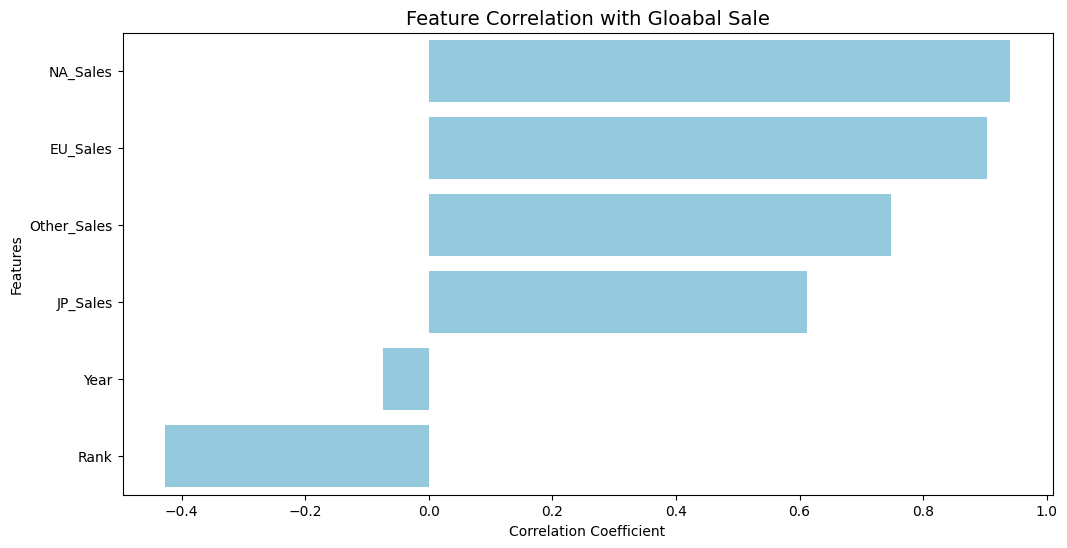

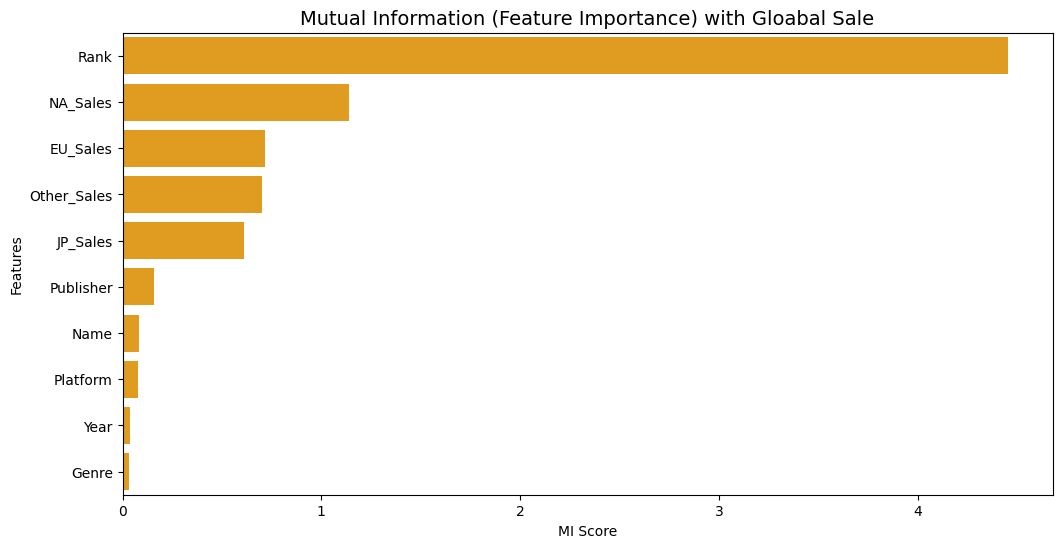

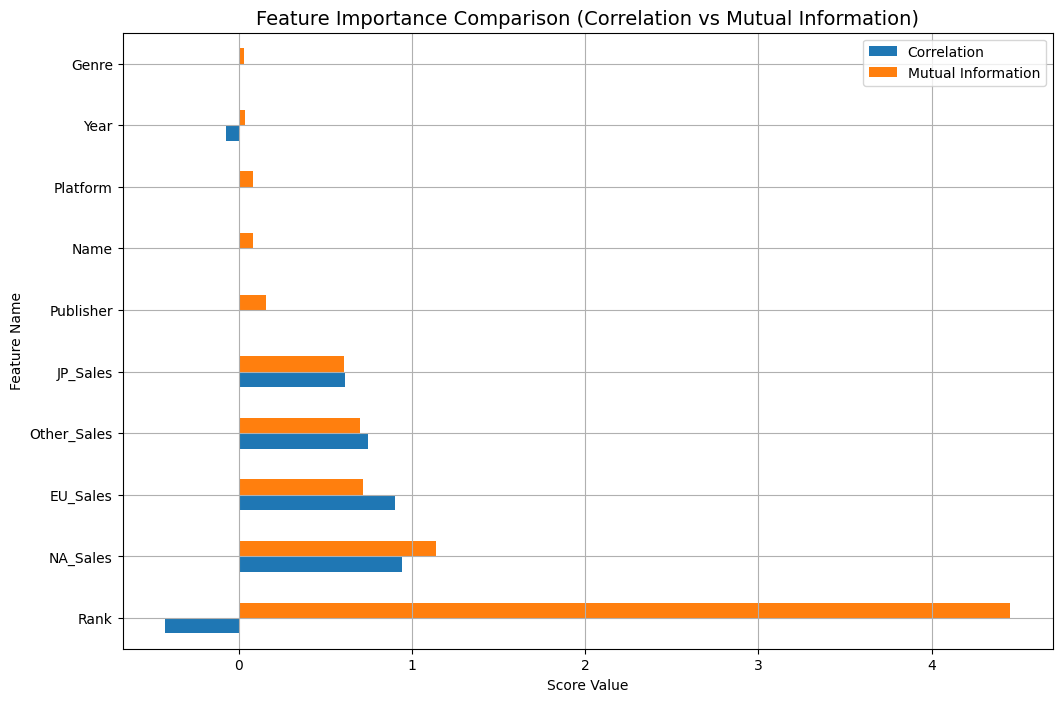

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Extract the independent and depenedent variables
X = df_copy.drop(columns=['Global_Sales'])
y = df_copy['Global_Sales']

# Correlation with target
corr = df.corr(numeric_only=True)
corr_target = corr["Global_Sales"].drop("Global_Sales").sort_values(ascending=False)

# Mutual Information (non-linear)
mi = mutual_info_regression(X, y)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Combine and visualize
plt.figure(figsize=(12,6))
sns.barplot(x=corr_target.values, y=corr_target.index, color='skyblue', label='Correlation')
plt.title("Feature Correlation with Gloabal Sale", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x=mi_scores.values, y=mi_scores.index, color='orange', label='Mutual Information')
plt.title("Mutual Information (Feature Importance) with Gloabal Sale", fontsize=14)
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.show()

# Combine both metrics side-by-side 
compare_df = pd.DataFrame({
    'Correlation': corr_target,
    'Mutual Information': mi_scores
}).sort_values(by='Mutual Information', ascending=False)

compare_df.plot(kind='barh', figsize=(12,8))
plt.title("Feature Importance Comparison (Correlation vs Mutual Information)", fontsize=14)
plt.xlabel("Score Value")
plt.ylabel("Feature Name")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Extract the independent and depenedent variables
X = df_copy.drop(columns=['Global_Sales'])
y = df_copy['Global_Sales']

# Split into  Train and test the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Scale the dataset and save the scalers
import pickle

from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with open("lasso_scalers.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Lasso scalers dumped successfully!")

Lasso scalers dumped successfully!


In [36]:
# Optuna objective function with Elastic Net
from sklearn.linear_model import Lasso

def objective(trial):
    # Suggest Hyperparameters
    alpha = trial.suggest_float('alpha', 1e-4, 1.0, log=True)
    max_iter = trial.suggest_int('max_iter', 200, 2000, step=200)
    tol = trial.suggest_float('tol', 1e-5, 1e-4, log=True)
    selection = trial.suggest_categorical('selection', ['cyclic', 'random'])
    positive = trial.suggest_categorical('positive', [True, False])
    precompute = trial.suggest_categorical('precompute', [True, False])
    fit_intercept = trial.suggest_categorical('fit_intercept', [True,False])

    # Build a model
    model = Lasso(
        alpha=alpha,
        max_iter=max_iter,
        tol=tol,
        selection=selection,
        positive=positive,
        precompute=precompute,
        fit_intercept=fit_intercept
    )
    
    # Cross validation for R2 score with 7 fold 
    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=7,
        n_jobs=-1,
        verbose=2
    )
    return np.mean(score)

In [37]:
# Optuna optimization
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Best hyperparameters and best score
print("Best Hyperparameters: ",study.best_params)
print("Best Score : ", study.best_value)

best_params = study.best_params

# Train with the best model
best_lasso = Lasso(
    alpha=best_params['alpha'],
    max_iter=best_params['max_iter'],
    tol=best_params['tol'],
    selection=best_params['selection'],
    positive=best_params['positive'],
    precompute=best_params['precompute'],
    fit_intercept=best_params['fit_intercept']
)

best_lasso.fit(X_train_scaled, y_train)
y_pred = best_lasso.predict(X_test_scaled)

[I 2025-10-31 10:09:33,840] A new study created in memory with name: no-name-4e3c8b5b-48de-41f7-9ca4-439c7f7e43fa


  0%|          | 0/30 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    2.6s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    2.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


[I 2025-10-31 10:09:36,644] Trial 0 finished with value: 0.840503811095246 and parameters: {'alpha': 0.000371286614469508, 'max_iter': 1400, 'tol': 2.4572037431959355e-05, 'selection': 'cyclic', 'positive': False, 'precompute': False, 'fit_intercept': False}. Best is trial 0 with value: 0.840503811095246.
[I 2025-10-31 10:09:36,798] Trial 1 finished with value: 0.9999645977169062 and parameters: {'alpha': 0.003980744447243019, 'max_iter': 1000, 'tol': 5.785812704286493e-05, 'selection': 'cyclic', 'positive': True, 'precompute': True, 'fit_intercept': True}. Best is trial 1 with value: 0.9999645977169062.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


...

[I 2025-10-31 10:09:40,477] Trial 24 finished with value: 0.9999833853652051 and parameters: {'alpha': 0.0008427622523206208, 'max_iter': 1800, 'tol': 1.8417035198226654e-05, 'selection': 'random', 'positive': False, 'precompute': False, 'fit_intercept': True}. Best is trial 21 with value: 0.9999844666273574.
[I 2025-10-31 10:09:40,641] Trial 25 finished with value: 0.9999844698435327 and parameters: {'alpha': 0.00010602589554129242, 'max_iter': 2000, 'tol': 1.775257652440121e-05, 'selection': 'random', 'positive': False, 'precompute': False, 'fit_intercept': True}. Best is trial 25 with value: 0.9999844698435327.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


[I 2025-10-31 10:09:40,794] Trial 26 finished with value: 0.8198535953531954 and parameters: {'alpha': 0.12824745413102664, 'max_iter': 1600, 'tol': 2.909882755542999e-05, 'selection': 'cyclic', 'positive': True, 'precompute': False, 'fit_intercept': False}. Best is trial 25 with value: 0.9999844698435327.
[I 2025-10-31 10:09:40,956] Trial 27 finished with value: 0.9999839122923166 and parameters: {'alpha': 0.0006172829672377738, 'max_iter': 1800, 'tol': 1.8427518709995358e-05, 'selection': 'random', 'positive': False, 'precompute': False, 'fit_intercept': True}. Best is trial 25 with value: 0.9999844698435327.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished


[I 2025-10-31 10:09:41,121] Trial 28 finished with value: 0.9999843149444503 and parameters: {'alpha': 0.00028662573129552683, 'max_iter': 2000, 'tol': 1.2154932539689802e-05, 'selection': 'random', 'positive': False, 'precompute': False, 'fit_intercept': True}. Best is trial 25 with value: 0.9999844698435327.
[I 2025-10-31 10:09:41,285] Trial 29 finished with value: 0.8404915640162366 and parameters: {'alpha': 0.00019759611556343252, 'max_iter': 1400, 'tol': 2.6929313342384333e-05, 'selection': 'cyclic', 'positive': False, 'precompute': False, 'fit_intercept': False}. Best is trial 25 with value: 0.9999844698435327.
Best Hyperparameters:  {'alpha': 0.00010602589554129242, 'max_iter': 2000, 'tol': 1.775257652440121e-05, 'selection': 'random', 'positive': False, 'precompute': False, 'fit_intercept': True}
Best Score :  0.9999844698435327


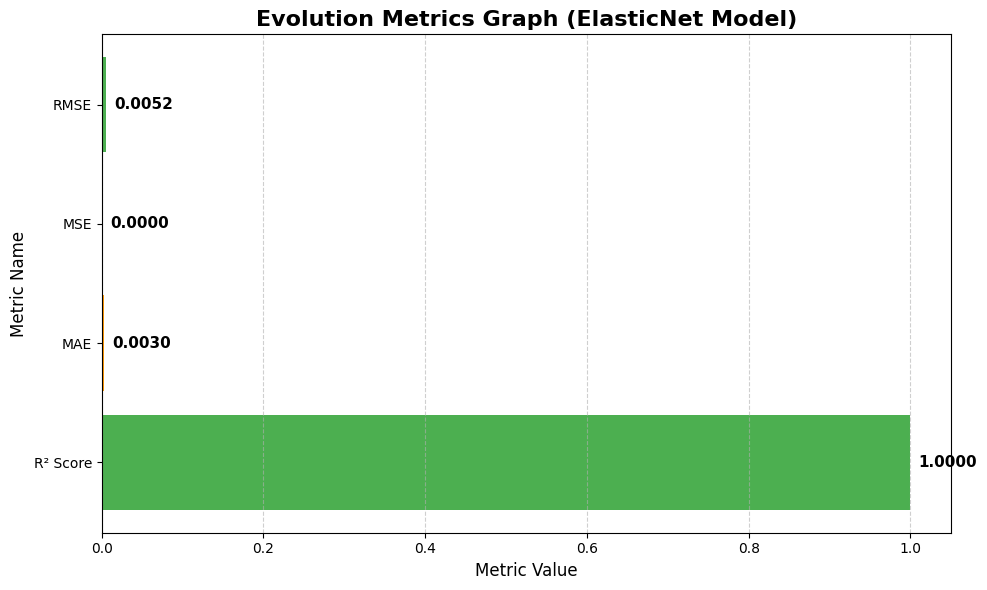

In [38]:
# Define metrics
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
}

# Create a figure
plt.figure(figsize=(10,6))

# Horizontal bar chart for better readability
plt.barh(list(metrics.keys()), list(metrics.values()), color=['#4CAF50', '#FF9800', '#2196F3'])

# Title and labels
plt.title('Evolution Metrics Graph (ElasticNet Model)', fontsize=16, fontweight='bold')
plt.xlabel('Metric Value', fontsize=12)
plt.ylabel('Metric Name', fontsize=12)

# Add metric values beside bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value + 0.01, i, f"{value:.4f}", va='center', fontsize=11, fontweight='bold')

# Grid and style
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

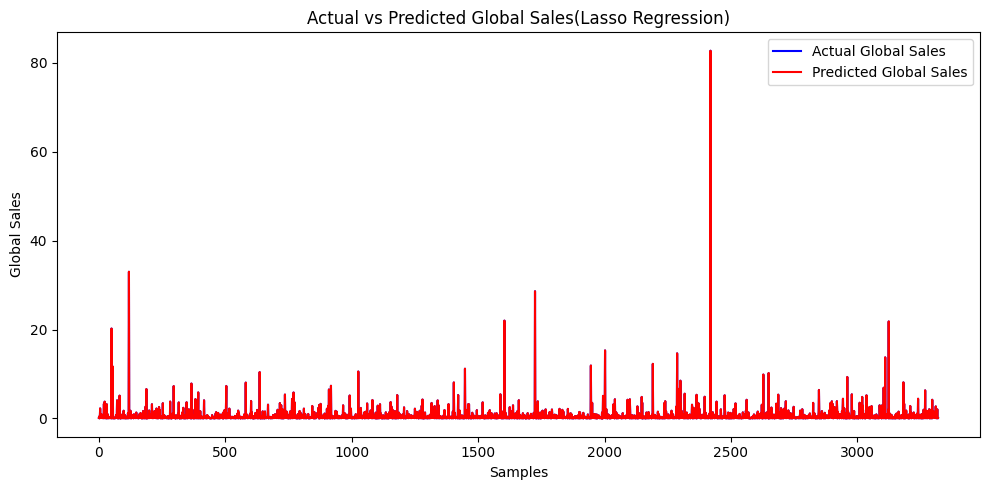

In [40]:
# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Global Sales', color='blue')
plt.plot(y_pred, label='Predicted Global Sales', color='red')
plt.title('Actual vs Predicted Global Sales(Lasso Regression)')
plt.xlabel('Samples')
plt.ylabel('Global Sales')
plt.legend()
plt.tight_layout()
plt.show()

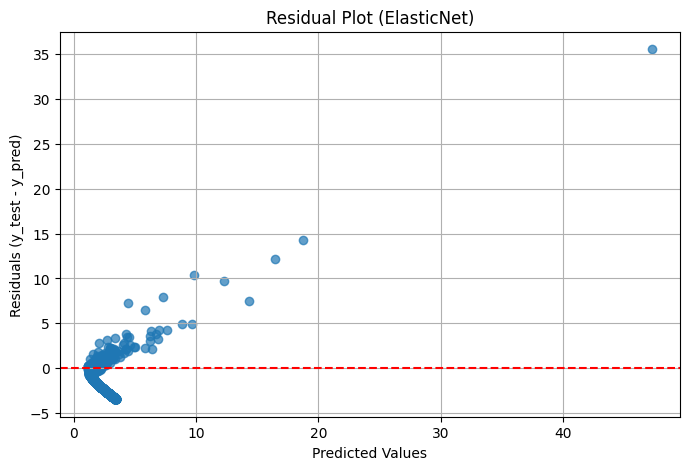

In [44]:
y_pred = best_lasso.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Residual plot (Predicted vs Residuals)
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (ElasticNet)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_test - y_pred)")
plt.grid(True)
plt.show()

In [48]:
# Import Optuna visualizations
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_contour,
    plot_param_importances,
    plot_edf,
    plot_slice
)

# Create list of all visualizations with descriptive names
plots = [
    ("Optimization History", plot_optimization_history(study)),
    ("Parallel Coordinate", plot_parallel_coordinate(study)),
    ("Contour Plot", plot_contour(study)),
    ("Parameter Importances", plot_param_importances(study)),
    ("Empirical Distribution Function (EDF)", plot_edf(study)),
    ("Parameter Slice Plot", plot_slice(study))
]

# Display all plots in loop with clear titles
for name, fig in plots:
    print(f"\n{name}")
    fig.show()


Optimization History



Parallel Coordinate



Contour Plot



Parameter Importances



Empirical Distribution Function (EDF)



Parameter Slice Plot


In [51]:
import joblib
from sklearn.pipeline import make_pipeline

# Create the pipeline
pipe = make_pipeline(scaler, best_lasso)
pipe.fit(X_train, y_train)

# Save the trained pipeline
joblib.dump(pipe, "lasso_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [52]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [56]:
import pandas as pd
import joblib

# Load the trained pipeline, encoders, and scalers
pipe = joblib.load("/kaggle/working/lasso_pipeline.pkl")
encoders = joblib.load("/kaggle/working/lasso_encoders.pkl")
scalers = joblib.load("/kaggle/working/lasso_scalers.pkl")

# New data for prediction
new_data = {
    "Rank": [1, 2, 3, 4, 5],
    "Name": ["Wii Sports", "Super Mario Bros.", "Mario Kart Wii", "Wii Sports Resort", "Pokemon Red/Pokemon Blue"],
    "Platform": ["Wii", "NES", "Wii", "Wii", "GB"],
    "Year": [2006.0, 1985.0, 2008.0, 2009.0, 1996.0],
    "Genre": ["Sports", "Platform", "Racing", "Sports", "Role-Playing"],
    "Publisher": ["Nintendo", "Nintendo", "Nintendo", "Nintendo", "Nintendo"],
    "NA_Sales": [41.49, 29.08, 15.85, 15.75, 11.27],
    "EU_Sales": [29.02, 3.58, 12.88, 11.01, 8.89],
    "JP_Sales": [3.77, 6.81, 3.79, 3.28, 10.22],
    "Other_Sales": [8.46, 0.77, 3.31, 2.96, 1.00]
}

df = pd.DataFrame(new_data)

# Encode categorical columns using the saved encoders
for col, encoder in encoders.items():
    if col in df.columns:
        df[col] = encoder.transform(df[col])

# Now predict using the pipeline
y_pred = pipe.predict(df)
print("Predicted Global Sales:", y_pred)

Predicted Global Sales: [82.7270785  40.23599306 35.82452438 32.99504905 31.37609374]


In [ ]:
# Import Optuna visualizations
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_contour,
    plot_param_importances,
    plot_edf,
    plot_slice
)

import os

# Create folder to save images
output_dir = "optuna_visualizations"
os.makedirs(output_dir, exist_ok=True)

# Create list of all visualizations with descriptive names
plots = [
    ("Optimization_History", plot_optimization_history(study)),
    ("Parallel_Coordinate", plot_parallel_coordinate(study)),
    ("Contour_Plot", plot_contour(study)),
    ("Parameter_Importances", plot_param_importances(study)),
    ("Empirical_Distribution_Function_EDF", plot_edf(study)),
    ("Parameter_Slice_Plot", plot_slice(study))
]

# Display and save all plots
for name, fig in plots:
    print(f"\nSaving {name} ...")
    fig.write_image(f"{output_dir}/{name}.png")  # Save as PNG
    fig.show()

print("\n✅ All Optuna visualizations saved in folder:", output_dir)

In [60]:
!pip install -U kaleido plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 58.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
